# What Yati's TF-IDF model gets wrong

A close reading of 20 false positives and 20 false negatives from `nlp-tfidf-tuned-v1`, the saved validation predictions that supersede the Week 1 baseline. I used the frozen validation outcomes and a score threshold of 0.50, the same threshold reported in Yati's tuning report. These scores are uncalibrated, so 0.50 is an audit convention, not a proposed lending cutoff.

The aim is to see what words the model responds to and what the descriptions actually say. A repayment outcome cannot be explained from the loan description alone.

## How the 40 cases were chosen

For each error type, I took the 10 predictions furthest across the 0.50 cutoff and drew 10 more from the remaining errors with a fixed random seed. That gives us obvious failures and less dramatic ones. It is still a deliberately mixed review sample, so the counts below describe these 40 cases, not every error in the validation set.

The code checks the saved prediction IDs, model version, frozen split, and published confusion matrix before selecting cases. Raw descriptions are loaded from the approved local CSV for review, but neither the descriptions nor title text appear in the saved notebook outputs. The case notes below paraphrase what I saw.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents]
            if (path / 'configs' / 'nlp_tfidf_v2.toml').exists())
sys.path.insert(0, str(ROOT))
from src.nlp.baseline_tfidf import load_baseline_split
from src.nlp.false_prediction_audit import (
    check_refit_scores, fit_published_model, load_validation_errors,
    select_review_cases, summarize_term_contributions,
)

DATA = ROOT / 'data'
METRICS = ROOT / 'reports' / 'nlp' / 'tfidf_tuning_metrics.json'
PREDICTIONS = DATA / 'nlp' / 'tfidf_oof_validate.parquet'
predictions = load_validation_errors(DATA, PREDICTIONS, METRICS)
cases = select_review_cases(predictions)
display(cases.groupby(['error_type', 'sample_group']).size().rename('cases').to_frame())
display(pd.crosstab(predictions['target'], predictions['prob_default_tfidf'].ge(0.5),
                    rownames=['Observed default'], colnames=['Flagged at 0.50']))

cases
error_type     sample_group       
false_negative random           10
               strongest        10
false_positive random           10
               strongest        10

Flagged at 0.50,False,True
Observed default,,
0,10054,8432
1,1398,1900


## Checking what pushed the score

I refit the published winning configuration on training text and check its scores against all 21,784 saved validation predictions. For a linear TF-IDF model, a term's contribution is its TF-IDF value multiplied by its fitted coefficient. For each reviewed case, the table counts the five largest contributions among terms seen in at least 50 training payloads. That frequency floor also keeps rare names or places out of the notebook output.

Overlapping terms can appear in the same case. For example, `rate` and `lower rate` may both be counted, so the column totals should not be added.

In [2]:
validation_text = load_baseline_split(DATA, 'validation')
model, train_text = fit_published_model(DATA, METRICS)
max_score_difference = check_refit_scores(model, validation_text, predictions)
selected_text = cases.merge(
    validation_text[['loan_id', 'purpose', 'title', 'desc', 'text_tfidf']],
    on='loan_id', how='left', validate='one_to_one'
)
assert selected_text['text_tfidf'].notna().all()
assert len(selected_text) == 40
term_counts = summarize_term_contributions(model, selected_text, len(train_text))
print(f'Maximum difference from saved validation scores: {max_score_difference:.2e}')
display(term_counts.loc[term_counts['case_count'].ge(2)]
        .groupby('error_type', sort=False).head(10)
        [['error_type', 'ngram', 'case_count', 'train_document_count']])

Maximum difference from saved validation scores: 6.02e-14


,error_type,ngram,case_count,train_document_count
0,false_negative,credit card,13,32200
1,false_negative,refinance,8,3124
2,false_negative,card,7,33050
3,false_negative,rate,6,12305
4,false_negative,lower rate,5,4199
5,false_negative,balance,3,3233
6,false_negative,card refinance,2,1303
7,false_negative,major purchase,2,2707
8,false_negative,paying,2,11124
9,false_negative,purchase,2,5285


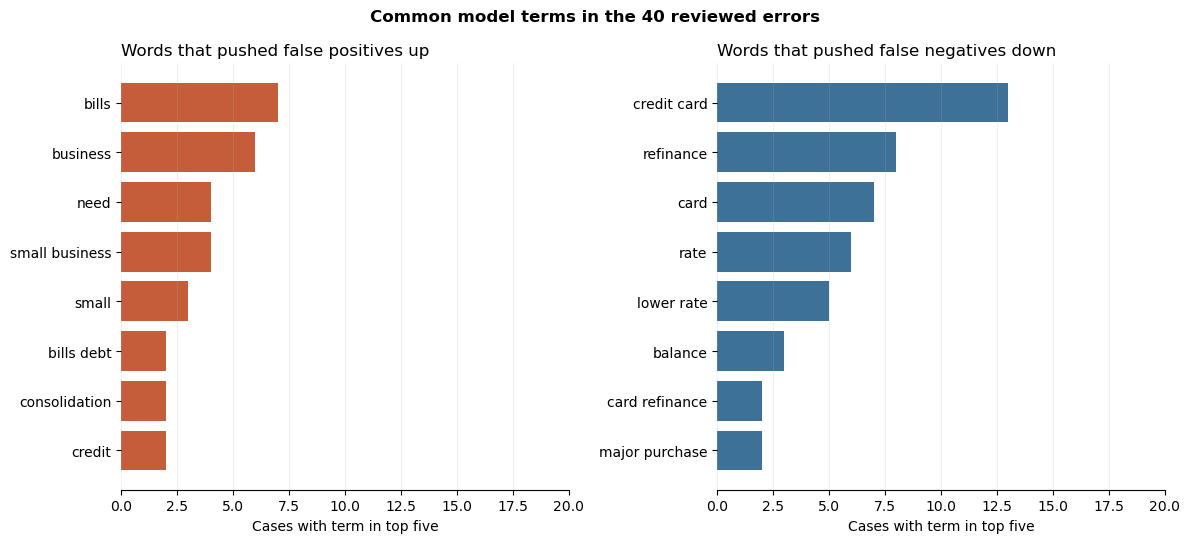

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, error_type, color, title in [
    (axes[0], 'false_positive', '#C65D3A', 'Words that pushed false positives up'),
    (axes[1], 'false_negative', '#3D7197', 'Words that pushed false negatives down'),
]:
    top = term_counts.loc[(term_counts.error_type.eq(error_type))
                          & (term_counts.case_count.ge(2))].head(8).iloc[::-1]
    ax.barh(top.ngram, top.case_count, color=color)
    ax.set_title(title, loc='left')
    ax.set_xlabel('Cases with term in top five')
    ax.set_xlim(0, 20)
    ax.grid(axis='x', alpha=0.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
fig.suptitle('Common model terms in the 40 reviewed errors', fontweight='bold')
fig.tight_layout()
plt.show()

## False positives: bills and business carry more weight than debt

Seven of the 20 reviewed false positives have `bills` among their five strongest upward terms. Six have `business`; only two have the standalone term `debt` in that group. Several of the strongest errors say little beyond paying bills, making one monthly payment, or using a business loan for stock or equipment. The model has almost no context in those short descriptions, yet familiar task words pull its score well above 0.50.

The fields matter too. In several cases, `business` appears in a title, a purpose, and the description. One loan is labelled `home_improvement` but describes a shop expansion; another is labelled `credit_card` but describes house work. Those mismatches make a single word count hard to read as the borrower's financial condition. One borrower explicitly reports a good job and credit history, and the score still lands just above the cutoff. Those are self-reported claims, not verified income or repayment capacity.

## False negatives: refinancing language often lowers the score

In 13 of the 20 reviewed false negatives, `credit card` is among the five largest downward terms. `Refinance` appears in eight, `rate` in six, and `lower rate` in five. Several actual defaulters wrote a short request to refinance cards at a better rate. The model read the vocabulary of a common, orderly loan purpose as reassuring. It had no way to see the later repayment outcome in the text.

The strongest false negatives are mostly terse, not polished essays. A ring, a truck, and a swimming pool also scored low because their purchase terms had large negative contributions. In the random half, a few descriptions mention multiple debts, attorney costs, or limited family help, yet the score stays below 0.50. That mix is a better description of what we saw than a single story about polished writing fooling the model.

## Notes on each reviewed case

These notes paraphrase the text and name the terms that mattered in the fitted model. They do not quote borrower descriptions. `Strongest` means furthest past the cutoff; `random` means a seeded draw from the other errors. The raw fields remain available locally in `selected_text` during an authorized run, but they are not saved in notebook output.

In [4]:
notes = {
    'lc_001745335': 'The description is only bills and savings. Business in the title and purpose adds a larger upward push than savings removes.',
    'lc_001687352': 'A two-word description about bills leaves almost nothing to offset the strong positive weight on bills.',
    'lc_001716137': 'The borrower says the loan is for a business. Business is nearly the entire upward contribution.',
    'lc_001723452': 'Paying bills through one lower monthly payment reads as debt management, but bills is the strongest upward term.',
    'lc_001694494': 'The description repeats bills and the wish for one payment. Several payment phrases add to the positive score.',
    'lc_001718446': 'Equipment and working cash are ordinary business uses. Business appears across fields and dominates the score.',
    'lc_001687750': 'Bills, a single payment, and a fresh start all push the score up despite the stated plan to simplify repayment.',
    'lc_001729365': 'A new store needs finishing funds and inventory. Business vocabulary carries the positive score.',
    'lc_001743856': 'Working capital is the entire description. Business appears in the title, purpose, and text.',
    'lc_001732042': 'The borrower asks to clear a card bill. Bills and need provide most of the upward push.',
    'lc_001715857': 'Replacing eight card payments with one sounds orderly, but payment phrases outweigh negative card terms.',
    'lc_001702726': 'The purpose says home improvement, while the description also discusses shop expansion and inventory. Business raises the score.',
    'lc_001711792': 'The borrower mentions medical bills and consolidation. The medical-bills phrase raises the score.',
    'lc_001707044': 'A short plan for one card payment receives positive weights for payment and card-pay phrases.',
    'lc_001696558': 'The home-improvement wording repeats across fields. The bigram improvement home is positive.',
    'lc_001677260': 'The purpose is credit card, but the title and description discuss house work. Need and money outweigh the card terms.',
    'lc_001733683': 'A very short card-payoff request gets a positive contribution from card-credit and card-payoff combinations.',
    'lc_001702097': 'The short consolidation description gives the model little beyond debt and consolidation.',
    'lc_001742113': 'Another brief consolidation description sits just above the threshold on debt-related terms.',
    'lc_001732776': 'The borrower reports a steady job, payment history, and good credit. Those phrases pull down, but the score remains just above 0.50.',
    'lc_001737619': 'A short card-refinance request scores very low because rate, lower rate, and refinance all push down.',
    'lc_001683920': 'An engagement-ring purchase has strong downward weights on ring and engagement.',
    'lc_001682326': 'The borrower wants a lower-rate card refinance. Rate and refinance outweigh the positive card terms.',
    'lc_001701903': 'Another card-refinance request at a lower rate. The same terms dominate the downward score.',
    'lc_001743877': 'An existing loan would be refinanced at a lower rate, with a shorter repayment period. Refinance and rate pull down.',
    'lc_001734894': 'The all-caps card-refinance request is brief; refinance, balance, and card terms pull down.',
    'lc_001691858': 'A better-rate card refinance looks routine in the text. Rate and refinance carry the downward contribution.',
    'lc_001680703': 'A truck purchase receives large negative weights for truck and purchase.',
    'lc_001739365': 'A pool, fence, and landscaping request receives a large negative weight for pool.',
    'lc_001679083': 'The borrower wants one lower-rate card balance. Rate, lower rate, and balance pull down.',
    'lc_001730276': 'The description repeats card debt and payoff. Credit-card terms still push the score below the cutoff.',
    'lc_001731693': 'A condo down payment sits alongside card payoff. Condo and card terms lower the score.',
    'lc_001702244': 'The borrower frames bank and card consolidation as convenient. Refinance in the title contributes downward.',
    'lc_001717626': 'Cards, a timeshare balance, and property taxes are combined into one payment. Balance and card terms pull down.',
    'lc_001735160': 'The description covers cards, insurance, and one payment. Saving and paying terms offset its positive payment words.',
    'lc_001679354': 'A very short card-refinance description still receives strong negative weights for refinance and credit card.',
    'lc_001710914': 'High-interest accounts and a plan to be debt-free are mentioned. The debt-free phrase lowers the score.',
    'lc_001730576': 'Attorney costs and a move away from family appear in the description. Help pushes up, but moved and costs pull down.',
    'lc_001677389': 'The borrower plans to cut up cards while consolidating. Card and consolidation phrases pull down.',
    'lc_001695513': 'High-interest card debt and a fixed APR appear in the text. APR and paying terms pull down.',
}
assert set(notes) == set(cases['loan_id'])
review = selected_text[['loan_id', 'error_type', 'sample_group', 'prob_default_tfidf', 'purpose']].copy()
review['observation'] = review['loan_id'].map(notes)
for kind in ['false_positive', 'false_negative']:
    print(kind.replace('_', ' ').title())
    display(review.loc[review.error_type.eq(kind)]
            .style.format({'prob_default_tfidf': '{:.3f}'}).hide(axis='index'))

False Positive


loan_id,error_type,sample_group,prob_default_tfidf,purpose,observation
lc_001745335,false_positive,strongest,0.826,small_business,The description is only bills and savings. Business in the title and purpose adds a larger upward push than savings removes.
lc_001687352,false_positive,strongest,0.817,other,A two-word description about bills leaves almost nothing to offset the strong positive weight on bills.
lc_001716137,false_positive,strongest,0.815,other,The borrower says the loan is for a business. Business is nearly the entire upward contribution.
lc_001723452,false_positive,strongest,0.793,debt_consolidation,"Paying bills through one lower monthly payment reads as debt management, but bills is the strongest upward term."
lc_001694494,false_positive,strongest,0.791,debt_consolidation,The description repeats bills and the wish for one payment. Several payment phrases add to the positive score.
lc_001718446,false_positive,strongest,0.788,small_business,Equipment and working cash are ordinary business uses. Business appears across fields and dominates the score.
lc_001687750,false_positive,strongest,0.784,debt_consolidation,"Bills, a single payment, and a fresh start all push the score up despite the stated plan to simplify repayment."
lc_001729365,false_positive,strongest,0.781,small_business,A new store needs finishing funds and inventory. Business vocabulary carries the positive score.
lc_001743856,false_positive,strongest,0.780,small_business,"Working capital is the entire description. Business appears in the title, purpose, and text."
lc_001732042,false_positive,strongest,0.779,debt_consolidation,The borrower asks to clear a card bill. Bills and need provide most of the upward push.


False Negative


loan_id,error_type,sample_group,prob_default_tfidf,purpose,observation
lc_001737619,false_negative,strongest,0.221,credit_card,"A short card-refinance request scores very low because rate, lower rate, and refinance all push down."
lc_001683920,false_negative,strongest,0.231,major_purchase,An engagement-ring purchase has strong downward weights on ring and engagement.
lc_001682326,false_negative,strongest,0.249,credit_card,The borrower wants a lower-rate card refinance. Rate and refinance outweigh the positive card terms.
lc_001701903,false_negative,strongest,0.254,credit_card,Another card-refinance request at a lower rate. The same terms dominate the downward score.
lc_001743877,false_negative,strongest,0.259,debt_consolidation,"An existing loan would be refinanced at a lower rate, with a shorter repayment period. Refinance and rate pull down."
lc_001734894,false_negative,strongest,0.266,credit_card,"The all-caps card-refinance request is brief; refinance, balance, and card terms pull down."
lc_001691858,false_negative,strongest,0.266,credit_card,A better-rate card refinance looks routine in the text. Rate and refinance carry the downward contribution.
lc_001680703,false_negative,strongest,0.267,major_purchase,A truck purchase receives large negative weights for truck and purchase.
lc_001739365,false_negative,strongest,0.269,home_improvement,"A pool, fence, and landscaping request receives a large negative weight for pool."
lc_001679083,false_negative,strongest,0.270,credit_card,"The borrower wants one lower-rate card balance. Rate, lower rate, and balance pull down."


## What to take forward

The confusion matrix contains 8,432 false positives and 1,398 false negatives at 0.50. The balanced class weights move scores upward in a dataset where only about 15% of validation loans defaulted. Many false positives at this cutoff are therefore expected. The 40-case audit adds a narrower finding: repeated bill and business vocabulary can dominate thin descriptions, while refinance and lower-rate vocabulary can make an eventual defaulter look reassuring to this model.

Before using a text score in a decision, test it alongside the tabular model and check its calibration. For text work, compare the current full payload with a description-only version and inspect errors by purpose and description length. This review does not tell us whether any particular borrower should have been approved or declined.

## Limits and reproduction

The sample includes 10 deliberately extreme errors per type, so its term counts are not population rates. The assigned outcome is `Fully Paid` or `Charged Off` in a historical LendingClub cohort; it does not reveal why a borrower repaid or defaulted. A negative coefficient means a term reduced this fitted model's score, not that the term protects borrowers. The purpose, title, and description share one TF-IDF vector, so overlapping phrases and field boundaries complicate a word-by-word explanation. The locked test split is not used.

Run this notebook from the repository or its `src/nlp` folder with the approved `data/raw/loan.csv` present. The checks and charts regenerate from the saved predictions, frozen manifest, and published tuning configuration. Keep the notebook output free of raw descriptions if you inspect `selected_text` locally.